# 09 — Inventory Optimization Analysis

Review:
- Recommended inventory
- Target inventory
- Forecast demand
- Recommended inventory actions

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

inventory = pd.read_csv(
    ROOT / "reports" / "inventory_optimization.csv"
)

print("Product-store combinations:", len(inventory))

display(inventory.head())

Product-store combinations: 130


,item_id,store_id,average_daily_demand,demand_std,demand_records,safety_stock,service_level,z_score,lead_time_days,lead_time_demand,...,inventory_level,forecast_demand,forecast_daily_average,forecast_peak_demand,forecast_horizon_demand,recommended_inventory,target_inventory,inventory_buffer,recommended_action,forecast_horizon_days
0,HOBBIES_1_209,CA_3,6.56,6.89,1857,30.00,0.95,1.645,7,45.92,...,High,181.90,6.50,10.15,45.48,75.48,75.92,30.44,Maintain High Stock,7
1,FOODS_1_021,CA_1,3.90,6.58,1857,28.63,0.95,1.645,7,27.30,...,High,56.67,2.02,3.67,14.17,42.80,55.93,41.76,Maintain High Stock,7
2,HOBBIES_1_209,CA_2,4.15,5.50,1857,23.95,0.95,1.645,7,29.05,...,High,97.59,3.49,6.49,24.40,48.35,53.00,28.60,Maintain High Stock,7
3,HOBBIES_1_209,CA_1,3.29,4.27,1857,18.57,0.95,1.645,7,23.03,...,High,110.37,3.94,6.51,27.59,46.16,46.16,18.57,Maintain High Stock,7
4,HOBBIES_1_209,TX_1,2.16,5.80,1857,25.25,0.95,1.645,7,15.12,...,High,65.02,2.32,4.13,16.25,41.50,41.50,25.25,Maintain High Stock,7


In [2]:
display(inventory.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,130,13,HOBBIES_1_209,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,130,10,CA_3,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_daily_demand,130.0,NaN,NaN,NaN,0.752538,0.947937,0.01,0.16,0.39,0.9675,6.56
demand_std,130.0,NaN,NaN,NaN,1.198,1.179263,0.14,0.4825,0.85,1.3875,6.89
demand_records,130.0,NaN,NaN,NaN,1857.0,0.0,1857.0,1857.0,1857.0,1857.0,1857.0
safety_stock,130.0,NaN,NaN,NaN,5.213615,5.132336,0.59,2.11,3.695,6.0325,30.0
service_level,130.0,NaN,NaN,NaN,0.95,0.0,0.95,0.95,0.95,0.95,0.95
z_score,130.0,NaN,NaN,NaN,1.645,0.0,1.645,1.645,1.645,1.645,1.645
lead_time_days,130.0,NaN,NaN,NaN,7.0,0.0,7.0,7.0,7.0,7.0,7.0
lead_time_demand,130.0,NaN,NaN,NaN,5.267769,6.635561,0.07,1.12,2.73,6.7725,45.92


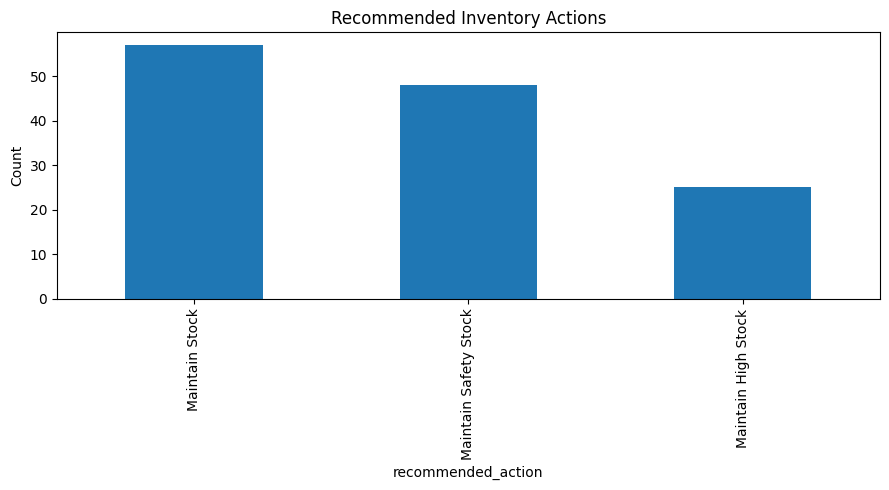

In [3]:
action_columns = [
    c for c in inventory.columns
    if c.lower() in [
        "recommended_action",
        "action",
        "inventory_action"
    ]
]

if action_columns:

    column = action_columns[0]

    inventory[column].value_counts().plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title("Recommended Inventory Actions")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

else:
    print("No inventory action column found.")